# Homework 2: Functions, Merging & Visualization

This assignment synthesizes concepts from the Week 4 practice notebooks. Use the table below as a reference for where each function was introduced.

### **Concept Reference Map**

| Category | Concept / Function | Original Reference Notebook |
| :--- | :--- | :--- |
| **Data Exploration** | `info()`, `columns`, `unique()`, `head()` | `1-visualization_basics.ipynb` |
| **Statistics** | `describe()`, `mean()`, `pct_change()` | `1-visualization_basics.ipynb` |
| **Manipulation** | `rename()`, `query()`, `drop()`, `set_index()` | `1-visualization_basics.ipynb` / `2-merging_practice.ipynb` |
| **Aggregation** | `groupby()` | `1-visualization_basics.ipynb` |
| **Time Series** | `pd.to_datetime()`, `PeriodIndex` | `2-merging_practice.ipynb` |
| **Merging** | `pd.merge()`, `pd.concat()` | `2-merging_practice.ipynb` |
| **Visualization** | `plot()`, `scatter()`, `barh()` | `1-visualization_basics.ipynb` |

---

## A. Importing Data

Run the cell below to load the WorldBank API function and download population and GDP data for G7 countries.

In [5]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

def get_wb_data(indicator, countries_list, start_year, end_year):
    country_str = ';'.join(countries_list)
    url = f'https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000'
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

## A.1 Show info

In [6]:
# CREATE Country list of G7 countries using ISO3 Codes
g7 = ['CAN', 'USA', 'JPN', 'DEU', 'FRA', 'GBR', 'ITA']

In [7]:
inflation_df = get_wb_data('FP.CPI.TOTL.ZG', g7, 2000, 2022)

inflation_df

,countryiso3code,date,value
0,CAN,2022,6.802801
1,CAN,2021,3.395193
2,CAN,2020,0.717000
3,CAN,2019,1.949269
4,CAN,2018,2.268226
...,...,...,...
156,USA,2004,2.677237
157,USA,2003,2.270095
158,USA,2002,1.586032
159,USA,2001,2.826171


## A.2 Show column names


In [8]:
inflation_df.columns

Index(['countryiso3code', 'date', 'value'], dtype='object')

## A.3 Show unique countries

In [9]:
inflation_df['countryiso3code'].unique()

array(['CAN', 'DEU', 'FRA', 'GBR', 'ITA', 'JPN', 'USA'], dtype=object)

# 1. Show GDP Growth for Japan using above data

## 1.A Rename column for country and value

In [10]:
# Rename country and value columns
inflation_df = inflation_df.rename(columns={
    'countryiso3code': 'country',
    'date': 'year',
    'value': 'inflation'
})
inflation_df.head(2)

,country,year,inflation
0,CAN,2022,6.802801
1,CAN,2021,3.395193


## 1.1 Create new data with only Japan

In [16]:
# Query japan
# YOUR CODE HERE
df_jp = inflation_df[inflation_df['country'] == 'JPN']
df_jp.head(2)

,country,year,inflation
115,JPN,2022,2.497703
116,JPN,2021,-0.233353


## 1.2 Set index as date, sort index, and drop country column

In [17]:
# Set index 
# YOUR CODE HERE
df_jp = df_jp.set_index('year')
df_jp.head(2)

,country,inflation
year,,
2022,JPN,2.497703
2021,JPN,-0.233353


In [18]:
# DROP country column
df_jp = df_jp.drop(columns=['country'])
df_jp.head(2)

,inflation
year,
2022,2.497703
2021,-0.233353


In [32]:
# Sort index makes it so date is descending
df_jp = df_jp.sort_index(ascending=False)
df_jp.head(2)
df_jp = df_jp.sort_index(ascending=True)
df_jp.head(2)

,inflation
year,
2000,-0.676579
2001,-0.740056


## 1.3 Plot

([<matplotlib.axis.XTick at 0x12867fb10>,
 [Text(0.0, 0, '2000'),
  Text(5.0, 0, '2005'),
  Text(10.0, 0, '2010'),
  Text(15.0, 0, '2015'),
  Text(20.0, 0, '2020')])

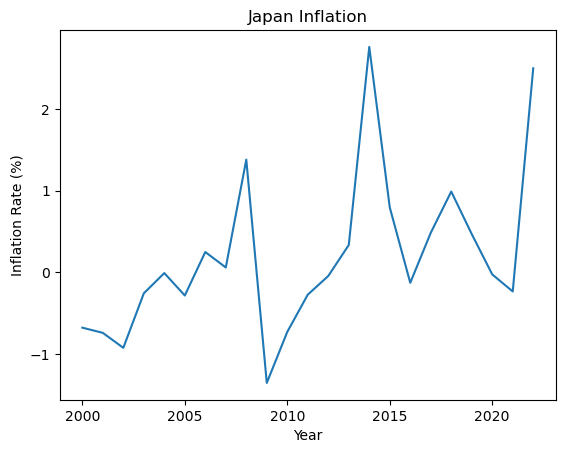

In [33]:
plt.figure()
plt.plot(df_jp.index, df_jp['inflation'])
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")    
plt.title("Japan Inflation");
plt.xticks(df_jp.index[::5])


# 2. Merging Data
## 2.A Importing data

In [34]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_gdp.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,6.0,0.020075,NaN
1,BR,1998,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,6.0,0.039924,NaN


In [35]:
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_govt_bond.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,11.062,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998,Brunei,14.424,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 2.1 Filter one country

In [36]:
df_govt_bond.economy.unique()

array(['BR', 'CN', 'HK', 'ID', 'JP', 'KH', 'KR', 'LA', 'MM', 'MY', 'PH',
       'SG', 'TH', 'VN'], dtype=object)

In [49]:
#MAKE SURE YOU query df_govt_bond
df_govt_bond_sg = df_govt_bond.query("economy == 'SG'")
df_govt_bond_sg.head(2)


,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
253,SG,1997,Singapore,-1.983,0.10,0.15,64.70364,1.0,143.449997,26.83,0.0,0.037272,0.0,0.0
254,SG,1998,Singapore,-5.663,0.15,0.25,85.38573,1.0,143.449997,33.89,0.0,0.029507,0.0,0.0


In [50]:
#MAKE SURE YOU GET GDP Data df_gdp
df_gdp_SG = df_gdp.query("economy == 'SG'")
df_gdp_SG.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
253,SG,1997,Singapore,37384.437008,141912.743489,2.850833,96.470305,3.708333,4.0,9.0,6.0,0.020075,2.387573
254,SG,1998,Singapore,35740.227354,140359.485488,2.837500,107.931074,4.000000,4.0,9.0,6.0,0.039924,1.197412


## 2.2 Filter gdp_pc_pp and set date as index

In [82]:
df_gdp_sg = get_wb_data('NY.GDP.PCAP.PP.CD', ['SGP'], 2000, 2022)
df_gdp_sg.head(2)

,countryiso3code,date,value
0,SGP,2022,143094.949897
1,SGP,2021,132617.354021


In [83]:

df_gdp_sg = df_gdp_sg.sort_values('date')
df_gdp_sg = df_gdp_sg.set_index('date')
df_gdp_sg.index
df_gdp_sg.head()

,countryiso3code,value
date,,
2000,SGP,43781.269150
2001,SGP,43109.064194
2002,SGP,45083.252990
2003,SGP,48778.298330
2004,SGP,54383.806233


## 2.3 Merge data

In [85]:
# NOTE I sorted index and drop na

df_merge = pd.merge(df_gdp_sg, df_govt_bond_sg, left_index=True, right_index=True, how='inner')
df_merge.head(2)

,countryiso3code,value,economy,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
date,,,,,,,,,,,,,,,
2000,SGP,43781.269150,SG,Singapore,-5.204,0.15,0.30,92.89428,1.0,143.449997,46.64,0.0,0.021441,0.0,0.0
2001,SGP,43109.064194,SG,Singapore,-4.593,0.10,0.25,95.94639,1.0,143.449997,62.98,0.0,0.015878,0.0,0.0


## 2.4 Convert to datetime

In [86]:
# No code changes needed
df_merge.index = pd.to_datetime(df_merge.index, format = "%Y")
df_merge.head(2)

,countryiso3code,value,economy,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
date,,,,,,,,,,,,,,,
2000-01-01,SGP,43781.269150,SG,Singapore,-5.204,0.15,0.30,92.89428,1.0,143.449997,46.64,0.0,0.021441,0.0,0.0
2001-01-01,SGP,43109.064194,SG,Singapore,-4.593,0.10,0.25,95.94639,1.0,143.449997,62.98,0.0,0.015878,0.0,0.0


In [87]:
df_merge.shape
df_merge.head()

,countryiso3code,value,economy,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
date,,,,,,,,,,,,,,,
2000-01-01,SGP,43781.269150,SG,Singapore,-5.204,0.15,0.30,92.89428,1.0,143.449997,46.64,0.0,0.021441,0.0,0.0
2001-01-01,SGP,43109.064194,SG,Singapore,-4.593,0.10,0.25,95.94639,1.0,143.449997,62.98,0.0,0.015878,0.0,0.0
2002-01-01,SGP,45083.252990,SG,Singapore,-1.197,0.10,0.25,98.30023,1.0,143.449997,64.00,0.0,0.015625,0.0,0.0
2003-01-01,SGP,48778.298330,SG,Singapore,-2.232,0.10,0.25,100.00000,1.0,143.449997,67.04,0.0,0.014916,0.0,0.0
2004-01-01,SGP,54383.806233,SG,Singapore,-0.678,0.10,0.15,97.88456,1.0,143.449997,67.11,0.0,0.014901,0.0,0.0


## 2.4 Plot net_borrow

Text(0, 0.5, '% GDP')

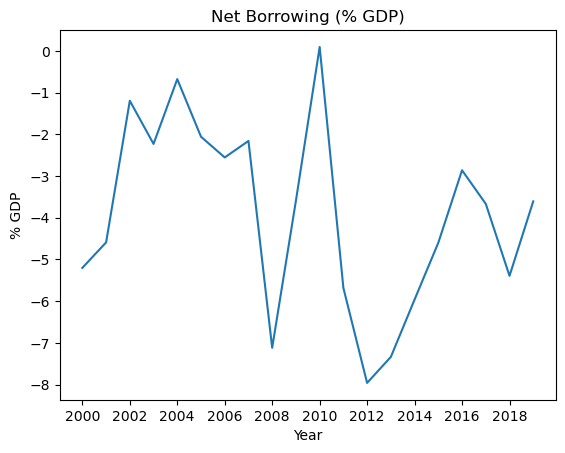

In [88]:
plt.figure()
plt.plot(df_merge.index, df_merge['net_borrow'])

plt.title("Net Borrowing (% GDP)")
plt.xlabel("Year")
plt.ylabel("% GDP")

# 3. Functions

## 3.A Import Data

In [92]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_merge_all = pd.concat([df_gdp, df_govt_bond], axis = 'columns')
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'economy', 'date',
       'country', 'net_borrow', 'kai', 'kao', 'bank_con', 'legor_uk',
       'dist_eq', 'bond_market_cap', 'bo_plbn_scaled', 'bo_siln_scaled',
       'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

In [93]:
df_merge_all = pd.merge(df_gdp, df_govt_bond, on=['economy', 'date', 'country'])
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'net_borrow', 'kai',
       'kao', 'bank_con', 'legor_uk', 'dist_eq', 'bond_market_cap',
       'bo_plbn_scaled', 'bo_siln_scaled', 'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

## 3.1 Create function to conver to datetime

In [94]:
def convert_date(df):
    df_copy = df.copy()
    df_copy['date'] = pd.to_datetime(df_copy['date'], format='%Y')
    return df_copy

In [97]:
df_merge_all = convert_date(df_merge_all)
df_merge_all.head(3)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997-01-01,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998-01-01,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
2,BR,1999-01-01,Brunei,63432.255561,20692.236087,NaN,60.176555,3.000000,3.000000,7.250000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


In [103]:
df_merge_all_converted = convert_date(df_merge_all)
df_merge_all_converted.head(3)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997-01-01,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998-01-01,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
2,BR,1999-01-01,Brunei,63432.255561,20692.236087,NaN,60.176555,3.000000,3.000000,7.250000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 3.2 Rename column function

/var/folders/40/jw4n_6k56fv479pmbvl84x5h0000gn/T/ipykernel_15257/1416856361.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_plot['gdp_pc_ppp'].pct_change(1),


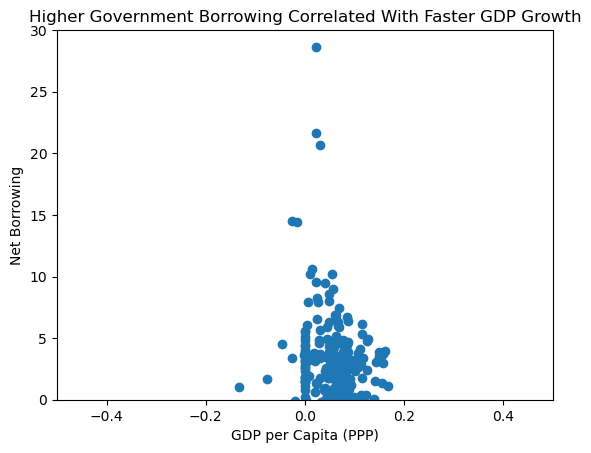

In [127]:
def plot_scatter(x_title, y_title, main_title):
    df_plot = df_merge_all_converted

    plt.scatter(
        df_plot['gdp_pc_ppp'].pct_change(1),
        df_plot['net_borrow']
    )

    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(main_title)
    plt.xlim(-0.5, 0.5)   
    plt.ylim(0, 30)
    plt.show()
plot_scatter('GDP per Capita (PPP)', 'Net Borrowing', 'Higher Government Borrowing Correlated With Faster GDP Growth')